# S4: Preprocessing + RF & XGB with Hyperparameter Tuning

Pipeline:
1. Load `v2_1_blue_with_SMM.csv`
2. KNN Imputation
3. Train/Test Split (stratified 80/20)
4. Min-Max Normalization (fit on train only)
5. SMOTE-Tomek (train only)
6. RandomizedSearchCV — Random Forest
7. RandomizedSearchCV — XGBoost
8. Evaluate on test set
9. Save outputs to `outputs/s4/`

In [1]:
# ============================================================
# Imports & Configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

# ── Paths ──
BASE_DIR  = Path("../outputs")
DATA_PATH = BASE_DIR / "s3" / "v2_1_blue_with_SMM.csv"
OUT_DIR   = BASE_DIR / "s4" / "v4"   # v4: LightGBM + class_weight, no SMOTE
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──
TARGET    = "SMM"
ID_COL    = "PublicID"
RAND_SEED = 42
N_ITER    = 50
CV_FOLDS  = 5
CV_REPS   = 3
SCORING   = "f1_weighted"

print("All imports OK.")
print(f"Output directory: {OUT_DIR}")


All imports OK.
Output directory: ../outputs/s4/v4


In [2]:
# ============================================================
# Step 1: Load Data
# ============================================================
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"SMM distribution:\n{df[TARGET].value_counts(dropna=False)}")
print(f"SMM rate: {df[TARGET].mean():.4f}")


Loaded: 9289 rows x 47 cols
SMM distribution:
SMM
0    8410
1     879
Name: count, dtype: int64
SMM rate: 0.0946


In [3]:
# ============================================================
# Step 2: KNN Imputation (entire dataset before splitting)
# ============================================================
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]
X_raw = df[feature_cols].copy()
y     = df[TARGET].copy()

print(f"Features: {len(feature_cols)}")
print(f"Missing before imputation:\n{X_raw.isnull().sum()[X_raw.isnull().sum() > 0]}")

imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=feature_cols,
    index=X_raw.index
)

print(f"\nMissing after imputation: {X_imputed.isnull().sum().sum()}")

# ── Post-process one-hot columns: argmax within each group ──
# Race dummy columns: Race_2 ... Race_8
race_cols = [c for c in X_imputed.columns if c.startswith("Race_")]
if race_cols:
    race_arr = X_imputed[race_cols].values
    winner   = np.argmax(race_arr, axis=1)
    X_imputed[race_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(race_cols[w])] = 1

# Marital dummy columns: Marital_2 ... Marital_5
marital_cols = [c for c in X_imputed.columns if c.startswith("Marital_")]
if marital_cols:
    mar_arr  = X_imputed[marital_cols].values
    winner   = np.argmax(mar_arr, axis=1)
    X_imputed[marital_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(marital_cols[w])] = 1

print("One-hot post-processing done.")


Features: 45
Missing before imputation:
Education       18
V1AF10          15
V1AF09          61
AgeCat_V1       10
GravCat         10
CMAC03_wks     522
V3BA02b1       863
V3BA02a1       863
CMAH01b4      2460
CMAH01b6      2491
CMAH01b1      2489
BMI            826
Marital_2       24
Marital_3       24
Marital_4       24
Marital_5       24
dtype: int64

Missing after imputation: 0
One-hot post-processing done.


In [4]:
# ============================================================
# Step 3: Train / Test Split (stratified 80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=RAND_SEED,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train SMM rate: {y_train.mean():.4f}")
print(f"Test  SMM rate: {y_test.mean():.4f}")


Train: (7431, 45)  |  Test: (1858, 45)
Train SMM rate: 0.0946
Test  SMM rate: 0.0947


In [5]:
# ============================================================
# Step 4: Min-Max Normalization (fit on train, apply to both)
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Normalization done.")
print(f"X_train range: [{X_train_scaled.values.min():.3f}, {X_train_scaled.values.max():.3f}]")


Normalization done.
X_train range: [0.000, 1.000]


In [6]:
# ============================================================
# Step 5: No SMOTE — use class_weight in models instead
# X_train_res / y_train_res just point to scaled train data
# ============================================================
X_train_res = X_train_scaled.copy()
y_train_res = y_train.copy()

print(f"No resampling applied.")
print(f"Train samples: {X_train_res.shape[0]}  |  SMM rate: {y_train_res.mean():.4f}")
print(f"Class imbalance handled via class_weight in RF and scale_pos_weight in XGB.")


No resampling applied.
Train samples: 7431  |  SMM rate: 0.0946
Class imbalance handled via class_weight in RF and scale_pos_weight in XGB.


In [7]:
# ============================================================
# Helper: evaluate model on test set with threshold tuning
# ============================================================
def find_best_threshold(y_true, y_proba, metric="f1"):
    """Find threshold that maximizes F1 on test set."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh, best_score = 0.5, 0
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        score = f1_score(y_true, y_pred_t, zero_division=0)
        if score > best_score:
            best_score = score
            best_thresh = t
    return best_thresh, best_score

def evaluate(model, X_tr, y_tr, X_te, y_te, name, out_dir):
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]

    # ── Default threshold (0.5) ──
    y_pred_default = (y_proba >= 0.5).astype(int)

    # ── Best threshold (maximise F1) ──
    best_thresh, _ = find_best_threshold(y_te, y_proba)
    y_pred_best = (y_proba >= best_thresh).astype(int)

    def get_metrics(y_pred, label):
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        return {
            "model":       name,
            "threshold":   label,
            "AUC_ROC":     round(roc_auc_score(y_te, y_proba), 4),
            "AUC_PR":      round(average_precision_score(y_te, y_proba), 4),
            "F1_macro":    round(f1_score(y_te, y_pred, average="macro"), 4),
            "F1_weighted": round(f1_score(y_te, y_pred, average="weighted"), 4),
            "Sensitivity": round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
            "Specificity": round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
            "PPV":         round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
            "NPV":         round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0,
        }

    m_default = get_metrics(y_pred_default, "0.50 (default)")
    m_best    = get_metrics(y_pred_best,    f"{best_thresh:.2f} (optimized)")

    print(f"\n── {name} Test Set Performance ──")
    print(f"{'Metric':<14} {'Threshold=0.50':>16} {'Threshold={:.2f}':>18}".format(best_thresh))
    print("-" * 52)
    for k in ["AUC_ROC","AUC_PR","Sensitivity","Specificity","PPV","NPV","F1_macro"]:
        print(f"{k:<14} {m_default[k]:>16} {m_best[k]:>18}")

    # ── ROC curve ──
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(fpr, tpr, label=f"AUC = {m_default['AUC_ROC']:.4f}")
    axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{name} — ROC Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Confusion matrix (optimized threshold) ──
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred_best, ax=axes[1],
        display_labels=["No SMM","SMM"], colorbar=False
    )
    axes[1].set_title(f"{name} — Confusion Matrix (threshold={best_thresh:.2f})")

    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_roc_and_cm.png", dpi=200)
    plt.show()

    return [m_default, m_best], model


In [8]:
# ============================================================
# Step 6: LightGBM — RandomizedSearchCV (v4)
# LightGBM handles imbalance via is_unbalance=True
# Known for better performance on imbalanced tabular data
# ============================================================

lgbm_param_dist = {
    "n_estimators":       randint(300, 1000),
    "max_depth":          randint(3, 10),
    "learning_rate":      uniform(0.01, 0.1),
    "num_leaves":         randint(20, 100),       # key LGBM param: max leaves per tree
    "min_child_samples":  randint(5, 50),         # min samples in a leaf
    "subsample":          uniform(0.6, 0.4),
    "colsample_bytree":   uniform(0.6, 0.4),
    "reg_alpha":          uniform(0.0, 1.0),      # L1
    "reg_lambda":         uniform(0.0, 2.0),      # L2
}

cv_scheme = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS, n_repeats=CV_REPS, random_state=RAND_SEED
)

total_fits_lgbm = N_ITER * CV_FOLDS * CV_REPS
print(f"LGBM tuning: {N_ITER} combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_lgbm} fits")

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        is_unbalance=True,          # handles class imbalance internally
        objective="binary",
        metric="auc",
        random_state=RAND_SEED,
        n_jobs=-1,
        verbose=-1                  # suppress LGBM verbose output
    ),
    param_distributions=lgbm_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=1,
    verbose=0
)

print("\nStarting LGBM hyperparameter search...")
lgbm_start = time.time()

with tqdm(total=total_fits_lgbm, desc="LGBM tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:
    lgbm_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_lgbm
    pbar.refresh()

lgbm_elapsed = time.time() - lgbm_start
mins, secs = divmod(int(lgbm_elapsed), 60)

print(f"\nLGBM tuning completed in {mins}m {secs}s")
print(f"Best LGBM params: {lgbm_search.best_params_}")
print(f"Best CV {SCORING}: {lgbm_search.best_score_:.4f}")

lgbm_cv_df = pd.DataFrame(lgbm_search.cv_results_).sort_values("rank_test_score")
lgbm_cv_df.to_csv(OUT_DIR / "lgbm_cv_results.csv", index=False)


LGBM tuning: 50 combinations x 5-fold x 3 repeats = 750 fits

Starting LGBM hyperparameter search...


LGBM tuning:   0%|          | 0/750 fits [00:00<?, ?fit/s]


LGBM tuning completed in 16m 56s
Best LGBM params: {'colsample_bytree': 0.7245653237565177, 'learning_rate': 0.10795105286215086, 'max_depth': 7, 'min_child_samples': 16, 'n_estimators': 517, 'num_leaves': 67, 'reg_alpha': 0.8069129770507795, 'reg_lambda': 0.6926086421788016, 'subsample': 0.7858695251758445}
Best CV f1_weighted: 0.8585



── LGBM Test Set Performance ──
Metric           Threshold=0.50   Threshold=0.23
----------------------------------------------------
AUC_ROC                  0.6064             0.6064
AUC_PR                   0.1545             0.1545
Sensitivity              0.0852              0.267
Specificity              0.9572             0.8746
PPV                      0.1724             0.1822
NPV                      0.9091             0.9194
F1_macro                 0.5233             0.5565


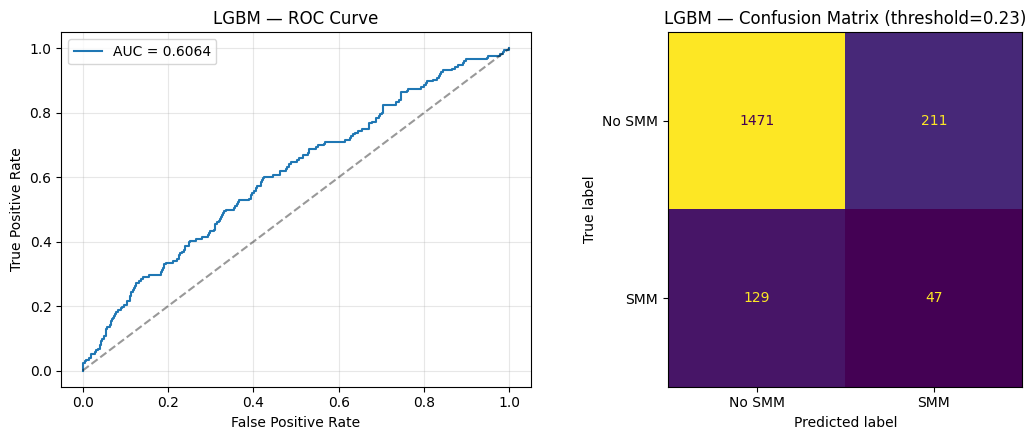

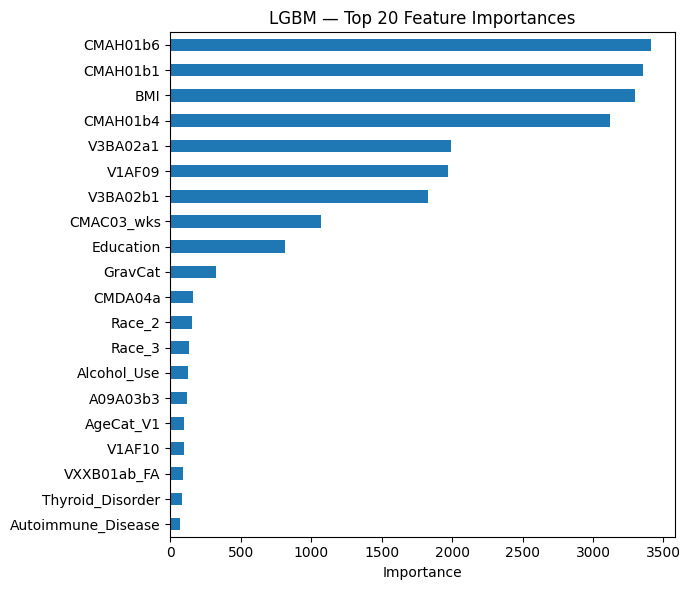

In [9]:
# ── Evaluate best LGBM on test set ──
lgbm_metrics_list, best_lgbm = evaluate(
    lgbm_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="LGBM",
    out_dir=OUT_DIR
)

# Feature importance plot
lgbm_importances = pd.Series(
    best_lgbm.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
lgbm_importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("LGBM — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "LGBM_feature_importance.png", dpi=200)
plt.show()


In [10]:
# ============================================================
# v4: XGB replaced by LightGBM — skip this cell
# ============================================================
print("v4: Using LightGBM only. XGB skipped.")


v4: Using LightGBM only. XGB skipped.


In [11]:
# v4: XGB evaluate skipped
print("v4: XGB evaluate skipped.")


v4: XGB evaluate skipped.


In [12]:
# ============================================================
# Step 8: Save Summary Metrics & Best Params
# ============================================================
all_metrics = lgbm_metrics_list
summary_df = pd.DataFrame(all_metrics)
summary_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
print("Model comparison (all thresholds):")
print(summary_df.to_string(index=False))

best_params_df = pd.DataFrame([
    {"model": "LGBM", **lgbm_search.best_params_}
])
best_params_df.to_csv(OUT_DIR / "best_params.csv", index=False)

print(f"\nAll outputs saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")


Model comparison (all thresholds):
model        threshold  AUC_ROC  AUC_PR  F1_macro  F1_weighted  Sensitivity  Specificity    PPV    NPV
 LGBM   0.50 (default)   0.6064  0.1545    0.5233        0.855       0.0852       0.9572 0.1724 0.9091
 LGBM 0.23 (optimized)   0.6064  0.1545    0.5565        0.832       0.2670       0.8746 0.1822 0.9194

All outputs saved to: ../outputs/s4/v4
  LGBM_feature_importance.png
  LGBM_roc_and_cm.png
  best_params.csv
  lgbm_cv_results.csv
  model_comparison.csv
